# 02 - Data Cleaning & Customer Satisfaction Analysis

A systematic data quality pass on the delivery dataset, followed by an investigation into whether delivery time affects customer satisfaction — and where the effect actually kicks in.


## Setup

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('/Users/DianaLara/Downloads/Orders.csv', encoding='UTF-16', sep='\t')
df.head()


,Order ID,Actual Delivery Date,Delay Reason,Driver ID,Driver Name,Hub Name,Is Delayed,Is On Time,Order Date,Order Status,Vehicle Name,Vehicle Type,Customer Satisfaction Score,Delivery Time Hours,Hub Processing Time Hours
0,1,25-10-2024,NaN,43,Karen Rodriguez,San Antonio Hub,False,True,25-10-2024,Delivered,FT-036,Truck,4,6.81,0.89
1,2,16-06-2024,NaN,29,Matthew Williams,Houston Hub,False,True,16-06-2024,Delivered,FT-016,Van,4,5.74,3.60
2,3,05-07-2024,NaN,25,Nancy Harris,Austin Hub,False,True,05-07-2024,Delivered,FT-040,Van,4,12.91,2.07
3,4,22-08-2023,NaN,20,David Davis,Fort Worth Hub,False,True,22-08-2023,Delivered,FT-039,Van,5,9.40,2.37
4,5,06-06-2024,Severe Weather,49,Joseph Williams,Dallas Main Hub,True,False,02-06-2024,Delivered,FT-018,Truck,3,103.48,1.80


## 1. Data Cleaning Checklist

Before trusting any correlation or comparison, run through a standard checklist: missing values, duplicates, data types, and sanity-checking value ranges.


### 1.1 Missing values (all columns)

In [2]:
# .to_string() prevents pandas from truncating the column list
print(df.isna().sum().to_string())


Order ID                           0
Actual Delivery Date             252
Delay Reason                   22071
Driver ID                          0
Driver Name                        0
Hub Name                           0
Is Delayed                         0
Is On Time                         0
Order Date                         0
Order Status                       0
Vehicle Name                       0
Vehicle Type                       0
Customer Satisfaction Score        0
Delivery Time Hours              252
Hub Processing Time Hours          0


**Finding:** only `Delivery Time Hours` and `Actual Delivery Date` have missing values (252 each), and both trace back to the 252 `Cancelled` orders. This is expected — a cancelled order was never delivered, so it has no delivery time or delivery date.


### 1.2 Duplicate rows and duplicate Order IDs

In [3]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate Order IDs: {df['Order ID'].duplicated().sum()}")


Duplicate rows: 0
Duplicate Order IDs: 0


**Finding:** no duplicate rows, no duplicate Order IDs. Each row is a unique order.


### 1.3 Data types

In [4]:
print(df.dtypes)


Order ID                         int64
Actual Delivery Date               str
Delay Reason                       str
Driver ID                        int64
Driver Name                        str
Hub Name                           str
Is Delayed                        bool
Is On Time                        bool
Order Date                         str
Order Status                       str
Vehicle Name                       str
Vehicle Type                       str
Customer Satisfaction Score      int64
Delivery Time Hours            float64
Hub Processing Time Hours      float64
dtype: object


### 1.4 Fixing date columns

`Order Date` and `Actual Delivery Date` loaded as text (`object`) rather than real dates. Converting them lets us do date math and time-based analysis later. The dataset uses day-first formatting (DD-MM-YYYY), so `dayfirst=True` is passed explicitly to avoid ambiguous dates (like 03-04-2024) being misread.


In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Actual Delivery Date'] = pd.to_datetime(df['Actual Delivery Date'], dayfirst=True, errors='coerce')

print(df['Order Date'].dtype)
print(df['Actual Delivery Date'].dtype)


datetime64[us]
datetime64[us]


In [6]:
# Confirm the conversion didn't introduce new missing values beyond the expected 252 cancellations
print(df['Order Date'].isna().sum())
print(df['Actual Delivery Date'].isna().sum())


0
252


**Finding:** `Order Date` has 0 missing values (every order has an order date, even cancelled ones), and `Actual Delivery Date` has exactly 252 missing — matching the cancelled orders exactly.


### 1.5 Range check on Customer Satisfaction Score

In [7]:
print(df['Customer Satisfaction Score'].describe())


count    27979.000000
mean         4.168662
std          0.862543
min          1.000000
25%          4.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: Customer Satisfaction Score, dtype: float64


**Finding:** scores range cleanly from 1-5 (a standard rating scale), with no out-of-range values. The mean (4.17) sits well above the scale midpoint, which means most customers rate their deliveries positively.

**Cleaning verdict:** the dataset is in good shape overall. The only missing data (252 rows) is fully explained by legitimate cancellations, not data quality issues. No rows needed to be dropped, imputed, or corrected.


## 2. Customer Satisfaction vs. Delivery Time

Does a longer delivery time actually correlate with a lower satisfaction score?


In [8]:
correlation = df['Delivery Time Hours'].corr(df['Customer Satisfaction Score'])
print(f"Correlation between Delivery Time and Satisfaction Score: {correlation:.3f}")


Correlation between Delivery Time and Satisfaction Score: -0.287


**Finding:** a correlation of **-0.287** — a real but weak-to-moderate negative relationship. Longer delivery times are associated with lower satisfaction, but delivery time alone doesn't explain most of the variation in ratings. As shown below, this weak correlation is partly because the true relationship isn't a straight line: it's flat, then drops sharply past a threshold, which a single correlation coefficient doesn't capture well.


### 2.1 Satisfaction by delay status

In [9]:
print(df.groupby('Is Delayed')['Customer Satisfaction Score'].mean())


Is Delayed
False    4.498301
True     2.937204
Name: Customer Satisfaction Score, dtype: float64


### 2.2 Satisfaction by delivery time bucket

Bucketing delivery time into ranges reveals patterns a straight-line correlation can miss, particularly whether satisfaction declines gradually or drops sharply past a certain point.


In [11]:
def time_bucket(hours):
    if hours < 24:
        return 'Under 1 day'
    elif hours < 72:
        return '1-3 days'
    elif hours < 120:
        return '3-5 days'
    else:
        return 'Over 5 days'

df['Delivery Time Bucket'] = df['Delivery Time Hours'].apply(time_bucket)
bucket_satisfaction = df.groupby('Delivery Time Bucket')['Customer Satisfaction Score'].mean().sort_values(ascending=False)
print(bucket_satisfaction)


Delivery Time Bucket
Under 1 day    4.304335
1-3 days       4.259635
3-5 days       3.043478
Over 5 days    1.778571
Name: Customer Satisfaction Score, dtype: float64


**Finding:** satisfaction does not decline steadily, it falls off a cliff after the 3-day mark:

| Delivery Time Bucket | Avg Satisfaction |
|---|---|
| Under 1 day | 4.30 |
| 1-3 days | 4.26 |
| 3-5 days | 3.04 |
| Over 5 days | 1.78 |

Satisfaction barely moves between 'Under 1 day' and '1-3 days,' but drops by over a full point once deliveries cross the 3-day mark, and falls off a cliff past 5 days. This suggests **72 hours (3 days) is a satisfaction tipping point**. This is a much more actionable insight than the correlation coefficient alone, since it points to a specific operational target rather than a vague 'delivery time matters' conclusion.


In [12]:
# How many orders actually fall into the 'danger zone' past 3 days?
print(df['Delivery Time Bucket'].value_counts())


Delivery Time Bucket
1-3 days       15776
Under 1 day    10173
3-5 days        1610
Over 5 days      420
Name: count, dtype: int64


<Axes: title={'center': 'Avg Satisfaction by Delivery Time Bucket'}, xlabel='Delivery Time Bucket'>

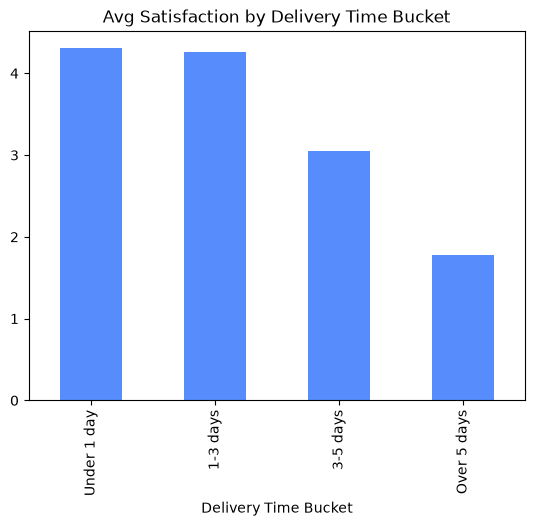

In [13]:
# Visualize the cliff-drop pattern (requires matplotlib: !pip install matplotlib)
bucket_satisfaction.plot(kind='bar', title='Avg Satisfaction by Delivery Time Bucket')


## Summary of Key Findings

**Data Cleaning**
- Dataset is clean overall: no duplicate rows or Order IDs, no out-of-range satisfaction scores.
- All missing values (252 rows, in `Delivery Time Hours` and `Actual Delivery Date`) are explained by legitimate order cancellations, not data errors.
- `Order Date` and `Actual Delivery Date` required explicit day-first parsing (`dayfirst=True`) to avoid ambiguous date misreads.

**Customer Satisfaction**
- Overall correlation between delivery time and satisfaction is weak (-0.287), but this understates the real pattern.
- Bucketed analysis reveals a clear tipping point: satisfaction is stable under 3 days, then drops sharply past 72 hours, and drops further past 120 hours.
- **Business implication:** keeping deliveries under the 3-day mark appears to be the key lever for maintaining customer satisfaction, rather than incremental improvements to already-fast deliveries.

**Next steps:** investigate what's driving deliveries past the 3-day threshold (which hubs/drivers/delay reasons are overrepresented in that group), and explore delivery performance trends over time using the now-cleaned `Order Date` column.
